# 04 · Mode shape vs DC bias and load

Reconstructs the mode-shape map at a list of (bias, load) conditions, and uses the
**bias dependence to separate the piezoresponse and electrostatic channels** — so the
D-ESBS comes out without switching PPLN domains.

The detected response is
```
    Z(x, f; V) = Z_piezo(x, f) + (V - V_cpd) · S_elec(x, f)
```
because the first-harmonic electrostatic force goes as (V_dc − V_cpd)·V_ac while the
piezoresponse does not depend on bias. A complex straight-line fit in V at each (x, f)
splits them: the **slope is the pure electrostatic channel** (exact — no V_cpd needed,
so the D-ESBS is rigorous) and the **intercept is the response at V = 0**, which still
carries a −V_cpd·S_elec term unless you supply `V_CPD`.

**Acquisition is organised per position, not per condition.** Moving the laser,
AutoWedge, InvOLS and engaging cost about a minute; changing bias costs a second. So
each position is visited once and every condition is measured there. That is several
times faster and — since the bias fit is per position — removes position-repeatability
error from the comparison.

Everything is checkpointed after each position, and resumes.

**Windows / Igor only.** Same setup as notebook 03: fixed tune window, no auto-recenter,
laser parked where `START_AT` says.

## 1 · Imports

In [31]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
import win32com.client
from activemodemap.asylum import AFMLaserSweepAutomation, AsylumInstrument
from activemodemap import (make_conditions, run_series, reconstruct_series,
                           separate_channels, estimate_v_cpd, channel_spots,
                           load_checkpoint, plot_state)

igor = win32com.client.Dispatch('IgorPro.Application')
print('Connected to Igor Pro')

Connected to Igor Pro


## 2 · Parameters

In [39]:
file_loc      = r'D:\User Data\Liam\ActiveModeMap\SCM_PIT\Bias Dependence'   # must exist
base_filename = 'AMapS'
os.makedirs(file_loc, exist_ok=True)

# --- geometry / reachable span (x = 0 is the clamped BASE) ---
PROBE_L_UM = 225.0
START_AT   = 'free_end'
REACH_UM   = 118.0
step_um    = 1.0
x_grid     = np.arange(PROBE_L_UM - REACH_UM, PROBE_L_UM + 1e-6, step_um)
HW_SIGN_TOWARD_FREE_END = +1

# --- conditions -----------------------------------------------------------
# At least 3 biases are needed for a testable linear fit (2 define a line exactly
# and leave no residual). Keep |V| below the coercive voltage or you will switch
# domains and the response stops being linear in bias -- the residual will tell you.
BIAS_V  = [-6.0,-3.0, 0.0, 3.0, 6.0]
LOAD_NN = [1000.0]                 # add more for a load series, e.g. [500, 1000, 2000]
conditions = make_conditions(BIAS_V, LOAD_NN, vary='bias_inner')

REF_INDEX = len(conditions) // 2   # the condition that drives position selection
V_CPD     = 0.0                    # set from KPFM if known; see estimate_v_cpd below

# --- reconstruction -------------------------------------------------------
DNS_BAND_HZ   = (270e3, 410e3)     # where to look for the resonance/null
RANK          = 4
MIN_POSITIONS = 6                  # = RANK + 2
MAX_POSITIONS = 14
DNS_CI_TOL_UM = 1.0
RECALIBRATE_EACH = True

CHECKPOINT = os.path.join(file_loc, 'series_checkpoint.npz')

n = len(conditions)
print(f'{n} conditions x ~{MAX_POSITIONS} positions')
print(f'~{n} tunes per position; laser move + calibrate + engage happens ONCE per position')
print('conditions:', [str(c) for c in conditions])

5 conditions x ~14 positions
~5 tunes per position; laser move + calibrate + engage happens ONCE per position
conditions: ['-6.000 V, 1000 nN', '-3.000 V, 1000 nN', '+0.000 V, 1000 nN', '+3.000 V, 1000 nN', '+6.000 V, 1000 nN']


## 3 · Instrument, direction check

In [33]:
automation = AFMLaserSweepAutomation(igor, file_loc, base_filename, log_filename=None)
automation.eigenmode_center_freq = float(np.mean(DNS_BAND_HZ))
automation.autowedge_pause = 15.0
automation.invols_bounds = (4e-8, 20e-7)
automation.resonance_band_Hz = DNS_BAND_HZ

# Wait for each tune to ACTUALLY finish rather than sleeping a fixed few seconds.
# Igor's CanttuneFunc only *starts* the sweep and returns immediately, so a fixed
# sleep that is shorter than the tune saves a partial spectrum AND lets the next
# condition's bias be applied while the current tune is still running — which
# corrupts exactly the bias dependence the channel separation relies on.
automation.wait_for_tune_complete = True     # leave True
automation.tune_timeout_s   = 180.0          # raise if your tune is slower
automation.tune_poll_s      = 0.4
automation.tune_stable_polls = 5             # ~2 s quiet window
automation.verbose_tune     = True           # prints how long each tune took

inst = AsylumInstrument(automation, load_nN=LOAD_NN[0], dc_bias_V=BIAS_V[0],
                        recalibrate_each=RECALIBRATE_EACH,
                        analysis_band_Hz=None,          # full spectrum to the fit
                        start_at=START_AT, span_um=PROBE_L_UM,
                        x_limits_um=(x_grid[0], x_grid[-1]),
                        hw_sign_toward_free_end=HW_SIGN_TOWARD_FREE_END)

# Walking inward from the free end every move should read "toward base".
inst.preview_moves(list(x_grid[::-20]))

start: x = 225.0 um (free end, 0.0 um from the free end)
  x = 0 is the clamped base; hw_sign_toward_free_end = +1
  x =   225.0 um   DoLDMove(    +0.0, 0)   no move
  x =   205.0 um   DoLDMove(   -20.0, 0)   toward base
  x =   185.0 um   DoLDMove(   -20.0, 0)   toward base
  x =   165.0 um   DoLDMove(   -20.0, 0)   toward base
  x =   145.0 um   DoLDMove(   -20.0, 0)   toward base
  x =   125.0 um   DoLDMove(   -20.0, 0)   toward base


## 3b · Picking up the tune-wait fix in a live kernel

Only needed once, if this kernel imported `activemodemap` before the tune-wait fix
landed. Two separate problems:

1. **Python caches modules**, so re-running cells re-runs the *old* code.
2. **A plain `importlib.reload` is not enough here.** The fix changes methods on
   `AFMLaserSweepAutomation` and adds attributes in its `__init__`. Reloading the
   module makes a *new* class object, but your existing `automation` and `inst` are
   still instances of the old one and keep the old methods. They must be rebuilt.

The cell below reloads and rebuilds both, carrying the tracked laser position
across so it is not lost - that is the one piece of state a restart would destroy.

**Also discard any checkpoint from a run made before the fix.** Those spectra were
saved mid-sweep, and `resume=True` would happily fold them into the new run.

In [34]:
import importlib
import activemodemap, activemodemap.lowrank, activemodemap.online, activemodemap.series
import activemodemap.asylum
for _m in (activemodemap.lowrank, activemodemap.online, activemodemap.asylum,
           activemodemap.series, activemodemap):
    importlib.reload(_m)
from activemodemap.asylum import AFMLaserSweepAutomation, AsylumInstrument
from activemodemap import (make_conditions, run_series, reconstruct_series,
                           separate_channels, estimate_v_cpd, channel_spots,
                           load_checkpoint)

# Carry the tracked laser position over. Software tracking is the only record of
# where the spot is; a fresh object would just assume START_AT and be wrong by
# however far the last run wandered.
try:
    _x_now = float(inst.current_x)
    print(f'carrying tracked position across: x = {_x_now:.1f} um')
except NameError:
    _x_now = float(x_grid[-1] if START_AT == 'free_end' else x_grid[0])
    print(f'no previous inst; assuming the laser is parked at x = {_x_now:.1f} um')
    print('  ^ VERIFY THIS OPTICALLY before running the series')

automation = AFMLaserSweepAutomation(igor, file_loc, base_filename, log_filename=None)
automation.eigenmode_center_freq = float(np.mean(DNS_BAND_HZ))
automation.autowedge_pause = 15.0
automation.invols_bounds = (4e-8, 200e-7)
automation.resonance_band_Hz = DNS_BAND_HZ
automation.wait_for_tune_complete = True
automation.tune_timeout_s    = 180.0
automation.tune_poll_s       = 0.4
automation.tune_stable_polls = 5
automation.verbose_tune      = True

inst = AsylumInstrument(automation, load_nN=LOAD_NN[0], dc_bias_V=BIAS_V[0],
                        recalibrate_each=RECALIBRATE_EACH, analysis_band_Hz=None,
                        x_start_um=_x_now,              # overrides start_at
                        span_um=PROBE_L_UM,
                        x_limits_um=(x_grid[0], x_grid[-1]),
                        hw_sign_toward_free_end=HW_SIGN_TOWARD_FREE_END)
print('rebuilt; wait_for_tune present:', hasattr(automation, 'wait_for_tune'))

# Any checkpoint written before the fix holds mid-sweep spectra: retire it.
if os.path.exists(CHECKPOINT):
    _old = CHECKPOINT + '.pre_tunewait'
    os.replace(CHECKPOINT, _old)
    print(f'retired the pre-fix checkpoint -> {os.path.basename(_old)}')
    print('  the series will start fresh rather than resuming contaminated data')

carrying tracked position across: x = 225.0 um
rebuilt; wait_for_tune present: True


## 4 · Run the series

Interrupt any time — the checkpoint holds every completed position, and re-running
this cell resumes from it rather than repeating measurements.

In [35]:
series = run_series(inst, x_grid, conditions,
                    ref_index=REF_INDEX, rank=RANK,
                    min_positions=MIN_POSITIONS, max_positions=MAX_POSITIONS,
                    dns_band_Hz=DNS_BAND_HZ, dns_ci_tol_um=DNS_CI_TOL_UM,
                    start_near_um=(x_grid[-1] if START_AT == 'free_end' else x_grid[0]),
                    checkpoint_path=CHECKPOINT, resume=True, verbose=True)
inst.close()
print(f"\n{series['x_um'].size} positions x {len(conditions)} conditions "
      f"x {series['freq_Hz'].size} frequencies")


=== position 1: x = 225.0 um (7 conditions) ===
      tune finished after 10.8 s
      cond 0: -6.00 V, 1000 nN -> 16000 pts, f_res 293.29 kHz
      tune finished after 10.5 s
      cond 1: -4.00 V, 1000 nN -> 16000 pts, f_res 293.21 kHz
      tune finished after 10.5 s
      cond 2: -2.00 V, 1000 nN -> 16000 pts, f_res 293.01 kHz
      tune finished after 10.5 s
      cond 3: +0.00 V, 1000 nN -> 16000 pts, f_res 294.01 kHz
      tune finished after 10.5 s
      cond 4: +2.00 V, 1000 nN -> 16000 pts, f_res 293.94 kHz
      tune finished after 10.7 s
      cond 5: +4.00 V, 1000 nN -> 16000 pts, f_res 293.80 kHz
      tune finished after 10.5 s
      cond 6: +6.00 V, 1000 nN -> 16000 pts, f_res 293.79 kHz

=== position 2: x = 166.0 um (7 conditions) ===
      tune finished after 10.8 s
      cond 0: -6.00 V, 1000 nN -> 16000 pts, f_res 293.42 kHz
      tune finished after 10.4 s
      cond 1: -4.00 V, 1000 nN -> 16000 pts, f_res 293.50 kHz
      tune finished after 10.5 s
      cond 2: 

## 5 · Reconstruct every condition

  -6.000 V, 1000 nN: f_res   293.30 kHz, D-NS  222.54 um, crossings [161.5 222.5]
  -4.000 V, 1000 nN: f_res   904.59 kHz, D-NS  142.53 um, crossings [120.4 142.5]
  -2.000 V, 1000 nN: f_res   904.81 kHz, D-NS  144.52 um, crossings [120.4 144.5]
  +0.000 V, 1000 nN: f_res   905.25 kHz, D-NS  145.50 um, crossings [120.3]
  +2.000 V, 1000 nN: f_res   293.30 kHz, D-NS  223.22 um, crossings [223.2]
  +4.000 V, 1000 nN: f_res   293.30 kHz, D-NS  223.06 um, crossings [223.1]
  +6.000 V, 1000 nN: f_res   293.30 kHz, D-NS  223.04 um, crossings [223.]


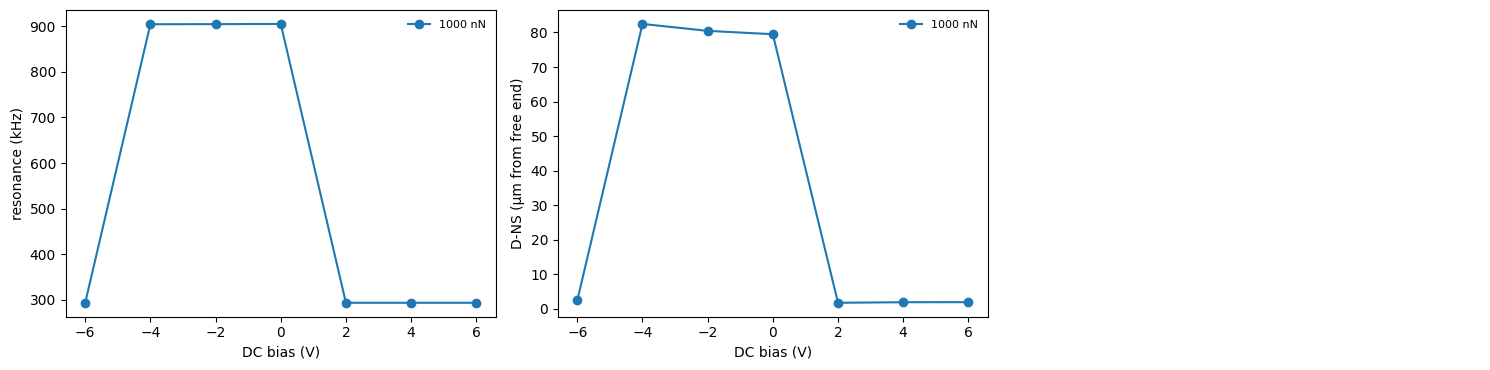

In [40]:
recs = reconstruct_series(series, x_grid, rank=RANK,
                          auto_band=True, band_halfwidth_Hz=70e3)

# auto_band re-centres the search on each condition's own resonance. That matters
# for a load series: contact stiffening moves the resonance by tens of kHz, and a
# band fixed at one load silently misses the peak at another.
ok = [r for r in recs if r is not None]
V  = np.array([r['condition'].bias_V for r in ok])
Ld = np.array([r['condition'].load_nN for r in ok])
fr = np.array([r['f_res_Hz'] for r in ok])
dn = np.array([r['dns_um'] for r in ok])

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
for L_ in np.unique(Ld):
    s = Ld == L_
    ax[0].plot(V[s], fr[s] / 1e3, 'o-', label=f'{L_:.0f} nN')
    ax[1].plot(V[s], PROBE_L_UM - dn[s], 'o-', label=f'{L_:.0f} nN')
ax[0].set_xlabel('DC bias (V)'); ax[0].set_ylabel('resonance (kHz)')
ax[1].set_xlabel('DC bias (V)'); ax[1].set_ylabel('D-NS (µm from free end)')
for a in ax[:2]:
    a.legend(fontsize=8, frameon=False)
if np.unique(Ld).size > 1:
    for v in np.unique(V):
        s = V == v
        ax[2].plot(Ld[s], PROBE_L_UM - dn[s], 'o-', label=f'{v:+.1f} V')
    ax[2].set_xlabel('load (nN)'); ax[2].set_ylabel('D-NS (µm from free end)')
    ax[2].legend(fontsize=8, frameon=False)
else:
    ax[2].axis('off')
plt.tight_layout()
fig.savefig(os.path.join(file_loc, 'Series_vs_condition.png'), dpi=150, bbox_inches='tight')

## 6 · Channel separation — D-NS and D-ESBS from the bias dependence

`rel_resid` is the linearity check. A response that is genuinely linear in bias gives
a residual at the noise level. A large residual means something else is going on —
domain switching at high |V|, electrostriction, or the contact drifting during the
sweep — and the separation should not be trusted.

In [41]:
LOAD_FOR_CHANNELS = LOAD_NN[0]

ch = separate_channels(series, load_nN=LOAD_FOR_CHANNELS, v_cpd=V_CPD)
print(f"linearity: peak residual {100*ch['rel_resid']:.1f}% of peak |Z|")

# V_cpd proxy: the bias minimising the total response, per position. It equals V_cpd
# only where the piezoresponse vanishes, so read it near the D-NS and treat it as a
# rough correction, not a calibrated KPFM number.
vcpd_per_pos, vcpd_med = estimate_v_cpd(ch, band_Hz=DNS_BAND_HZ)
print(f'V_cpd proxy: median {vcpd_med:+.3f} V across positions')

spots = channel_spots(ch, x_grid, rank=RANK, band_Hz=DNS_BAND_HZ)
print(f"\nD-NS   = {PROBE_L_UM - spots['dns']['value_um']:.2f} µm from the free end")
print(f"D-ESBS = {PROBE_L_UM - spots['desbs']['value_um']:.2f} µm from the free end")
print('\nNote the two use different estimators on purpose: the D-NS is the '
      'antiresonance branch crossing, the D-ESBS a spatial null of the '
      'electrostatic channel at resonance. The branch crossing cannot '
      'distinguish the channels — it gives the same position for both.')

linearity: peak residual 4.8% of peak |Z|
V_cpd proxy: median -2.317 V across positions
  D-NS   (piezo, branch crossing)      : 223.75 um
  D-ESBS (electrostatic, spatial null) : 222.85 um  [at 293.4 kHz, not quasistatic]
  linearity: peak residual 4.8% of peak |Z| (large => response not linear in bias: domain switching, or the contact drifted during the sweep)

D-NS   = 1.25 µm from the free end
D-ESBS = 2.15 µm from the free end

Note the two use different estimators on purpose: the D-NS is the antiresonance branch crossing, the D-ESBS a spatial null of the electrostatic channel at resonance. The branch crossing cannot distinguish the channels — it gives the same position for both.


saved Series_result.npz, Series_channels.png, Series_vs_condition.png


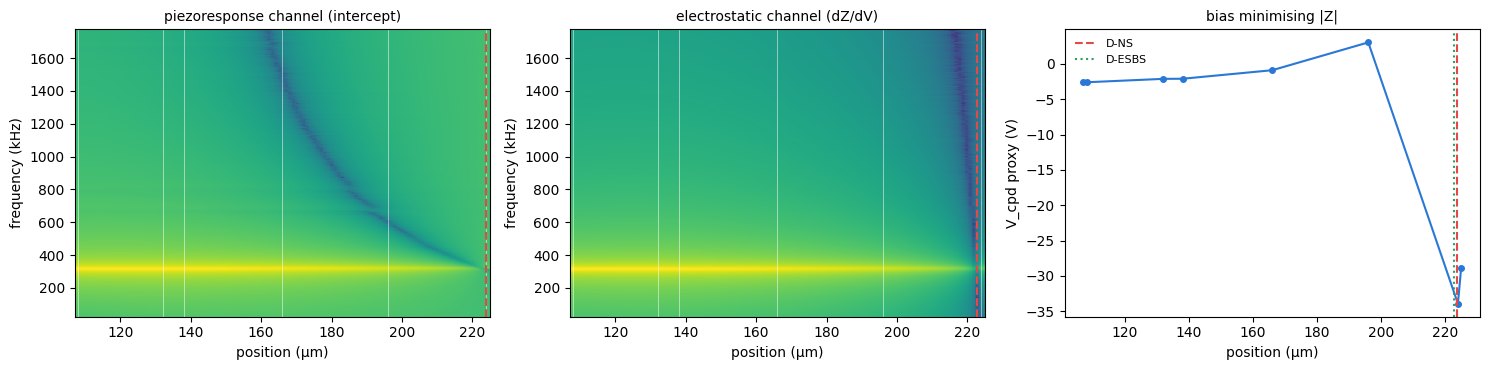

In [42]:
# the two channel maps side by side
f_k = ch['freq_Hz'] / 1e3
ext = [x_grid[0], x_grid[-1], f_k[0], f_k[-1]]
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
for a, key, ttl, spot in ((ax[0], 'dns', 'piezoresponse channel (intercept)', 'dns'),
                          (ax[1], 'desbs', 'electrostatic channel (dZ/dV)', 'desbs')):
    M = np.abs(spots[key]['Zrec']).T
    a.imshow(np.log10(M + 1e-14), origin='lower', aspect='auto', extent=ext, cmap='viridis')
    for xv in series['x_um']:
        a.axvline(xv, color='w', lw=0.5, alpha=0.7)
    a.axvline(spots[spot]['value_um'], color='#e34948', ls='--', lw=1.5)
    a.set_title(ttl, fontsize=10); a.set_xlabel('position (µm)'); a.set_ylabel('frequency (kHz)')
ax[2].plot(ch['x_um'], vcpd_per_pos, 'o-', color='#2a78d6', ms=4)
ax[2].axvline(spots['dns']['value_um'], color='#e34948', ls='--', label='D-NS')
ax[2].axvline(spots['desbs']['value_um'], color='#2f9e5f', ls=':', label='D-ESBS')
ax[2].set_xlabel('position (µm)'); ax[2].set_ylabel('V_cpd proxy (V)')
ax[2].legend(fontsize=8, frameon=False); ax[2].set_title('bias minimising |Z|', fontsize=10)
plt.tight_layout()
fig.savefig(os.path.join(file_loc, 'Series_channels.png'), dpi=150, bbox_inches='tight')

np.savez(os.path.join(file_loc, 'Series_result.npz'),
         x_um=series['x_um'], freq_Hz=series['freq_Hz'], Z=series['Z'],
         x_grid=x_grid, bias_V=ch['bias_V'], load_nN=ch['load_nN'],
         piezo=ch['piezo'], elec=ch['elec'], resid=ch['resid'], v_cpd=V_CPD,
         dns_um=spots['dns']['value_um'], desbs_um=spots['desbs']['value_um'],
         probe_L_um=PROBE_L_UM)
print('saved Series_result.npz, Series_channels.png, Series_vs_condition.png')

## Notes

- **Signal-to-noise sets whether this works.** The D-NS comes from the antiresonance
  notch, ~2 % of the resonance peak deep. What matters is noise relative to the
  off-resonance baseline; in simulation the recovery held from 2 % to 50 % of
  baseline. If the map shows many branch crossings scattered along the beam, the
  notch is unresolvable — average longer or narrow the tune window. Smoothing does
  not help: wide enough to suppress the wiggles also erases the notch.
- **Keep |V| below the coercive voltage.** Switching domains mid-sweep breaks the
  linear-in-bias assumption; `rel_resid` is the diagnostic.
- **Each tune is waited out, not slept through.** `wait_for_tune` polls the Igor
  tune waves — tracking the NaN sweep front — until they stop changing, then
  applies `tune_settling_time`. If a tune exceeds `tune_timeout_s` the record is
  flagged `tune_completed=False` and the run prints `** TUNE DID NOT COMPLETE **`;
  treat those spectra as suspect rather than trusting them.
- **Load changes re-engage by default** (`set_load(reengage=True)`). A large setpoint
  jump while in contact drives the tip into the surface.
- The load series needs `auto_band=True`: the contact resonance stiffens with load.
- Only the reference condition drives position selection, so all conditions share a
  position set and are directly comparable.